## РАСЧЕТ ИНДЕКСА ОБЕСПЕЧЕННОСТИ

### ИМПОРТЫ

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


# warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

### ЗАГРУЗКА ДАННЫХ

In [2]:
# ---- пути к файлам ----
city_crs = 28409
SCENARIO = 'scen_1'
SCENARIO_ISO = 'scen_1'
BUILDINGS_PATH = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\houses.gpkg'      # жилые здания
ISOCHRONES_PATH  = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO_ISO}\isochrones_final.gpkg'    # 500-м изохроны объединенные
DISCTRICT_PATN = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\district.gpkg' # кварталы

buildings  = gpd.read_file(BUILDINGS_PATH)
isochrones = gpd.read_file(ISOCHRONES_PATH)
districts = gpd.read_file(DISCTRICT_PATN)

buildings = buildings.to_crs(isochrones.crs)
districts = districts.to_crs(isochrones.crs)

### ОБЪЕДИНЕНИЕ ИЗОХРОН в 3 полигона по категориям

In [3]:
iso_dissolved = (
    isochrones
    .dissolve(by='rank')
    .reset_index()[['rank', 'geometry']]
)

In [4]:
iso_dissolved[iso_dissolved['rank'] == 1].explore()

### ПРОСТРАНСТВЕННОЕ СОЕДИНЕНИЕ

In [5]:
buildings = buildings.reset_index(drop=True)
buildings['address_id'] = buildings.index

joined = gpd.sjoin(
    buildings,
    iso_dissolved,
    how='inner',
    predicate='within'
)

### УСТАНОВКА ПРИОРИТЕТА

In [6]:
priority_map = {
    1: 1,
    2: 2,
    3: 3
}
joined['priority'] = joined['rank'].map(priority_map)

best = (
    joined
    .sort_values('priority', ascending=True)
    .drop_duplicates(subset='address_id', keep='first')
)

### АГРЕГАЦИЯ

In [7]:
cats = [1, 2, 3]

result    = best.groupby('rank')['popul'].sum().reindex(cats).fillna(0)
count_bld = best.groupby('rank')['address_id'].count().reindex(cats).fillna(0)

total_all = buildings['popul'].sum()
total_in  = result.sum()
total_out = total_all - total_in

outside_ids  = set(buildings['address_id']) - set(best['address_id'])
bld_outside  = buildings[buildings['address_id'].isin(outside_ids)]

### ИНДЕКС УРОВНЯ ОБЕСПЕЧЕННОСТИ

In [8]:
# ============================================================
#    ИОН = (pop_1 + pop_2 × 0.5) / pop_всего
# ============================================================
pop_1 = result.get(1, 0)
pop_2 = result.get(2, 0)
pop_3 = result.get(3, 0)

service_index = (pop_1 + pop_2 * 0.25 + pop_3 * 0.1) / total_all

In [9]:
result

rank
1    437153
2     48415
3     51952
Name: popul, dtype: int32

### СВОДНАЯ ТАБЛИЦА

In [10]:
labels_map = {
    1: '1 ранг',
    2: '2 ранг',
    3: '3 ранг'
}

summary = pd.DataFrame({
    'Категория':        [labels_map[c] for c in cats] + ['Вне изохрон'],
    'Население':        list(result.values.astype(int)) + [int(total_out)],
    'Доля %':           list((result.values / total_all * 100).round(2)) +
                        [round(total_out / total_all * 100, 2)],
    'Кол-во зданий':    list(count_bld.values.astype(int)) + [len(bld_outside)],
})

print(summary.to_string(index=False))
print(f'\nИндекс уровня обеспеченности: {service_index:.4f}  ({service_index*100:.2f} %)')

  Категория  Население  Доля %  Кол-во зданий
     1 ранг     437153    73.3           2204
     2 ранг      48415     8.1            308
     3 ранг      51952     8.7            244
Вне изохрон      58841     9.9            267

Индекс уровня обеспеченности: 0.7620  (76.20 %)


### ВИЗУАЛИЗАЦИЯ

Сохранение отдельных графиков:
 -> Saved: X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\scen_1\pic\scen_1_population_coverage_01_pop_bars.png
 -> Saved: X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\scen_1\pic\scen_1_population_coverage_02_pie_share.png
 -> Saved: X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\scen_1\pic\scen_1_population_coverage_03_pie_cover.png
 -> Saved: X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\scen_1\pic\scen_1_population_coverage_04_bld_bars.png
 -> Saved: X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\scen_1\pic\scen_1_population_coverage_05_index_gauge.png


C:\Users\glazo\AppData\Local\Temp\ipykernel_22292\1921075693.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.96])


'X:\\00_ЛабГрад_ПО\\09_Сотрудники\\Глазов Ю.А\\izhevsk\\4_result\\scen_1\\pic\\scen_1_population_coverage.png'

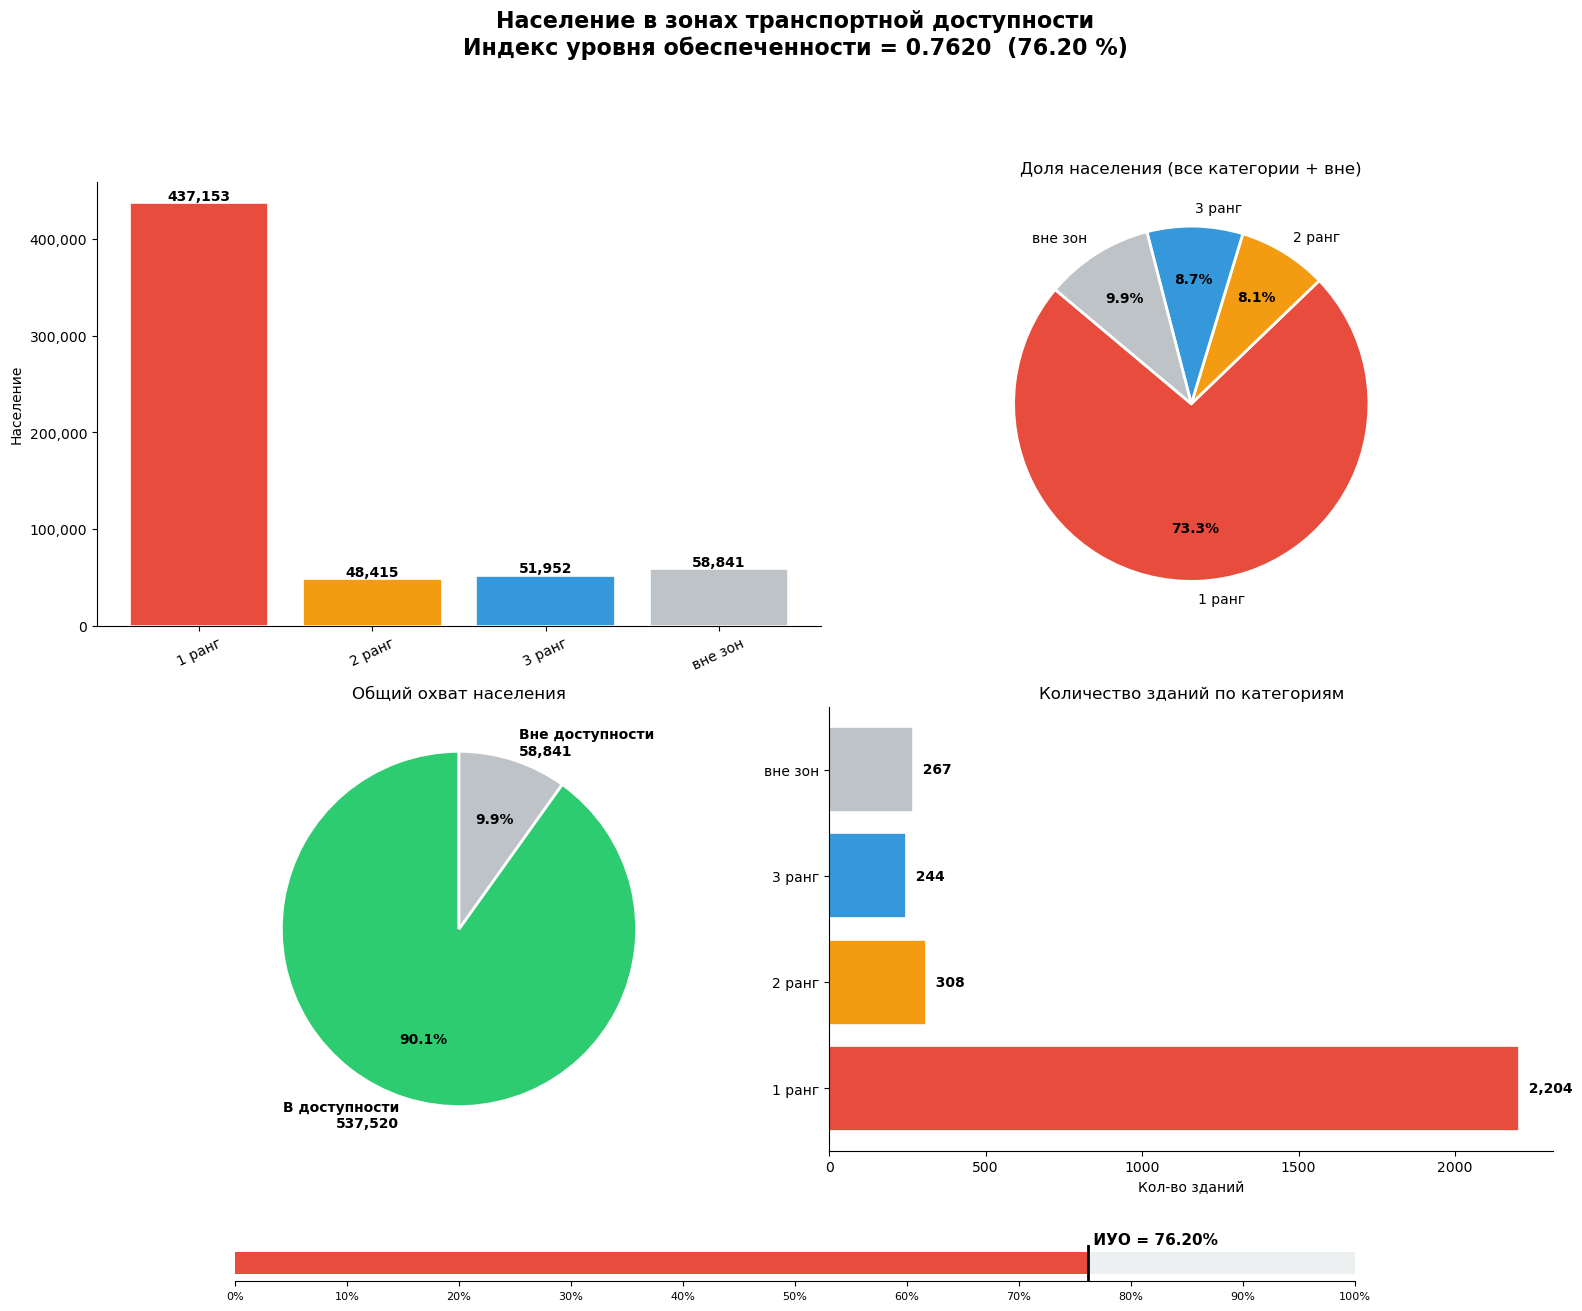

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from IPython.display import display, HTML

# ---------- палитра ----------
colors = {
    '1 ранг':       '#e74c3c',
    '2 ранг': '#f39c12',
    '3 ранг':             '#3498db',
    'вне':                 '#bdc3c7'
}
labels_map = {
    '1 ранг': '1 ранг',
    '2 ранг': '2 ранг',
    '3 ранг': '3 ранг',
    'вне':                 'вне зон'
}

cats_ext   = ['1 ранг', '2 ранг', '3 ранг', 'вне']
vals_ext   = list(result.values) + [total_out]
colors_ext = [colors[c] for c in cats_ext]
labels_ext = [labels_map[c] for c in cats_ext]

bld_counts_ext = list(count_bld.values.astype(int)) + [len(bld_outside)]

# ============================================================
# ФУНКЦИИ ДЛЯ ОТРИСОВКИ ОТДЕЛЬНЫХ ГРАФИКОВ
# ============================================================

def draw_plot1(ax):
    """Население по категориям"""
    bars = ax.bar(labels_ext, vals_ext, color=colors_ext,
                   edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals_ext):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Население')
    # ax.set_title('Население по категориям')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top', 'right']].set_visible(False)

def draw_plot2(ax):
    """Доля населения (круговая)"""
    wedges, texts, autotexts = ax.pie(
        vals_ext,
        labels=labels_ext,
        colors=colors_ext,
        autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
        startangle=140,
        pctdistance=0.7,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for t in autotexts:
        t.set_fontweight('bold')
    ax.set_title('Доля населения (все категории + вне)')

def draw_plot3(ax):
    """Общий охват населения"""
    cover_vals   = [total_in, total_out]
    cover_labels = [f'В доступности\n{total_in:,.0f}', f'Вне доступности\n{total_out:,.0f}']
    cover_colors = ['#2ecc71', '#bdc3c7']
    ax.pie(
        cover_vals,
        labels=cover_labels,
        colors=cover_colors,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.65,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops=dict(fontweight='bold')
    )
    ax.set_title('Общий охват населения')

def draw_plot4(ax):
    """Количество зданий"""
    hbars = ax.barh(labels_ext, bld_counts_ext, color=colors_ext,
                     edgecolor='white', linewidth=1.2)
    for bar, val in zip(hbars, bld_counts_ext):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 f'  {int(val):,}', ha='left', va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel('Кол-во зданий')
    ax.set_title('Количество зданий по категориям')
    ax.spines[['top', 'right']].set_visible(False)

def draw_plot_gauge(ax):
    """Шкала индекса уровня обеспеченности"""
    # Рисуем полосу
    ax.barh(0, 1, color='#ecf0f1', height=0.6)
    ax.barh(0, service_index, color='#e74c3c', height=0.6)
    
    # Настройка осей
    ax.set_xlim(0, 1)
    # Фиксируем пределы Y, чтобы шкала не растягивалась по высоте
    ax.set_ylim(-0.5, 0.5) 
    
    ax.set_yticks([])
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f'{int(x*100)}%' for x in np.arange(0, 1.1, 0.1)], fontsize=8)
    
    # Линия индикатора
    ax.axvline(service_index, color='black', linewidth=2)
    
    # Текст над линией
    ax.text(service_index, 0.45,
              f' ИУО = {service_index*100:.2f}%',
              va='bottom',
              ha='left' if service_index < 0.8 else 'right',
              fontsize=11, fontweight='bold')
    
    # ax.set_title('Индекс уровня обеспеченности', fontsize=11, pad=25)
    ax.spines[['top', 'left', 'right']].set_visible(False)

# ============================================================
# 1. СОЗДАНИЕ И СОХРАНЕНИЕ ОТДЕЛЬНЫХ ГРАФИКОВ
# ============================================================

save_path = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\pic\{SCENARIO}_population_coverage.png'
base_dir = os.path.dirname(save_path)
base_fname = os.path.splitext(os.path.basename(save_path))[0] # без расширения

# Список графиков: (функция, суффикс, размер фигуры)
plots_to_export = [
    (draw_plot1, '_01_pop_bars', (8, 6)),
    (draw_plot2, '_02_pie_share', (8, 6)),
    (draw_plot3, '_03_pie_cover', (8, 6)),
    (draw_plot4, '_04_bld_bars', (8, 6)),
    (draw_plot_gauge, '_05_index_gauge', (8, 1.5))
]

print("Сохранение отдельных графиков:")
for func, suffix, figsize in plots_to_export:
    fig_s, ax_s = plt.subplots(figsize=figsize, facecolor='white')
    func(ax_s) # Вызов функции отрисовки
    plt.tight_layout()
    
    # Формирование пути
    single_fname = f"{base_fname}{suffix}.png"
    single_path = os.path.join(base_dir, single_fname)
    
    plt.savefig(single_path, dpi=200, bbox_inches='tight')
    plt.close(fig_s) 
    print(f" -> Saved: {single_path}")

# ============================================================
# 2. СОЗДАНИЕ ОБЩЕЙ КАРТИНКИ (DASHBOARD)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='white')
fig.suptitle(
    f'Население в зонах транспортной доступности\n'
    f'Индекс уровня обеспеченности = {service_index:.4f}  ({service_index*100:.2f} %)',
    fontsize=16, fontweight='bold', y=1.02
)

# Заполняем сетку основными графиками
draw_plot1(axes[0, 0])
draw_plot2(axes[0, 1])
draw_plot3(axes[1, 0])
draw_plot4(axes[1, 1])

# ---------- Добавляем шкалу (используя ту же функцию) ----------
# Создаем ось для шкалы в нижней части figure
ax_gauge = fig.add_axes([0.15, -0.04, 0.7, 0.03])
draw_plot_gauge(ax_gauge)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])

# Сохранение общей картинки
plt.savefig(save_path, dpi=200, bbox_inches='tight')

# Вывод пути и показ общей картинки
display(save_path)
plt.show()

## РАСЧЕТ РАЙОНОВ

In [12]:
buildings['address_id'] = buildings['address_id'].astype(str)
best['address_id'] = best['address_id'].astype(str)


bld_in_districts = gpd.sjoin(
    buildings[['address_id', 'popul', 'geometry']],
    districts[['name', 'geometry']],
    how='inner',
    predicate='within'
)

### ПРИВЯЗКА ЗДАНИЙ К РАЙОНАМ

In [13]:
buildings['address_id'] = buildings['address_id'].astype(str)
best['address_id'] = best['address_id'].astype(str)

GROUP = 'name' # по какой колонке группировать

bld_in_districts = gpd.sjoin(
    buildings[['address_id', 'popul', 'geometry']],
    districts[[GROUP, 'geometry']],
    how='inner',
    predicate='within'
)

In [14]:
# ============================================================
# 3. ПОДТЯГИВАЕМ КАТЕГОРИЮ ИЗ БЛОКА 1
# ============================================================
bld_in_districts = bld_in_districts.merge(
    best[['address_id', 'rank']],
    on='address_id',
    how='left'
)
bld_in_districts['rank'] = bld_in_districts['rank'].fillna('вне')

In [15]:
# ============================================================
# 4. АГРЕГАЦИЯ ПО РАЙОНАМ
# ============================================================
pop_total = (
    bld_in_districts
    .groupby(GROUP)['popul'].sum()
    .rename('pop_total')
)
pop_1 = (
    bld_in_districts[bld_in_districts['rank'] == 1]
    .groupby(GROUP)['popul'].sum()
    .rename('pop_1')
)
pop_2 = (
    bld_in_districts[bld_in_districts['rank'] == 2]
    .groupby(GROUP)['popul'].sum()
    .rename('pop_2')
)
pop_3 = (
    bld_in_districts[bld_in_districts['rank'] == 3]
    .groupby(GROUP)['popul'].sum()
    .rename('pop_3')
)
pop_out = (
    bld_in_districts[bld_in_districts['rank'] == 'вне']
    .groupby(GROUP)['popul'].sum()
    .rename('pop_out')
)

In [16]:
# ============================================================
# 5. СВОДНАЯ ТАБЛИЦА
# ============================================================
district_stats = (
    pd.concat([pop_total, pop_1, pop_2, pop_3, pop_out], axis=1)
    .fillna(0)
    .astype(int)
)

# Процент обеспеченности маршрутами 1 ранга
district_stats['pct_1r'] = (
    district_stats['pop_1'] / district_stats['pop_total'] * 100
).round(2)

# Индекс обеспеченности маршрутами по районам
district_stats['iom'] = (
    (district_stats['pop_1'] + district_stats['pop_2'] * 0.25)
    / district_stats['pop_total'] * 100
).round(2)

# Процент общего охвата (все ранги)
district_stats['pct_cover'] = (
    (district_stats['pop_1'] + district_stats['pop_2'] + district_stats['pop_3'])
    / district_stats['pop_total'] * 100
).round(2)

district_stats = district_stats.sort_values('pct_1r', ascending=False)

print('Обеспеченность маршрутами 1 ранга по районам:\n')
print(district_stats.to_string())
print(f'\nСреднее по городу: {district_stats["iom"].mean():.2f} %')
print(f'Медиана:           {district_stats["iom"].median():.2f} %')

Обеспеченность маршрутами 1 ранга по районам:

       pop_total  pop_1  pop_2  pop_3  pop_out  pct_1r   iom  pct_cover
name                                                                   
d_1         1152   1152      0      0        0   100.0 100.0      100.0
d_100        994    994      0      0        0   100.0 100.0      100.0
d_101       2565   2565      0      0        0   100.0 100.0      100.0
d_103       1462   1462      0      0        0   100.0 100.0      100.0
d_105       9082   9082      0      0        0   100.0 100.0      100.0
d_104       3176   3176      0      0        0   100.0 100.0      100.0
d_110      14390  14390      0      0        0   100.0 100.0      100.0
d_108       2524   2524      0      0        0   100.0 100.0      100.0
d_130        327    327      0      0        0   100.0 100.0      100.0
d_13         838    838      0      0        0   100.0 100.0      100.0
d_12        2680   2680      0      0        0   100.0 100.0      100.0
d_122       7730 

In [17]:
# ============================================================
# 6. ПРИСОЕДИНЯЕМ СТАТИСТИКУ К ГЕОМЕТРИИ
# ============================================================
districts_viz = districts.merge(
    district_stats,
    left_on=GROUP,
    right_index=True,
    how='left'
)

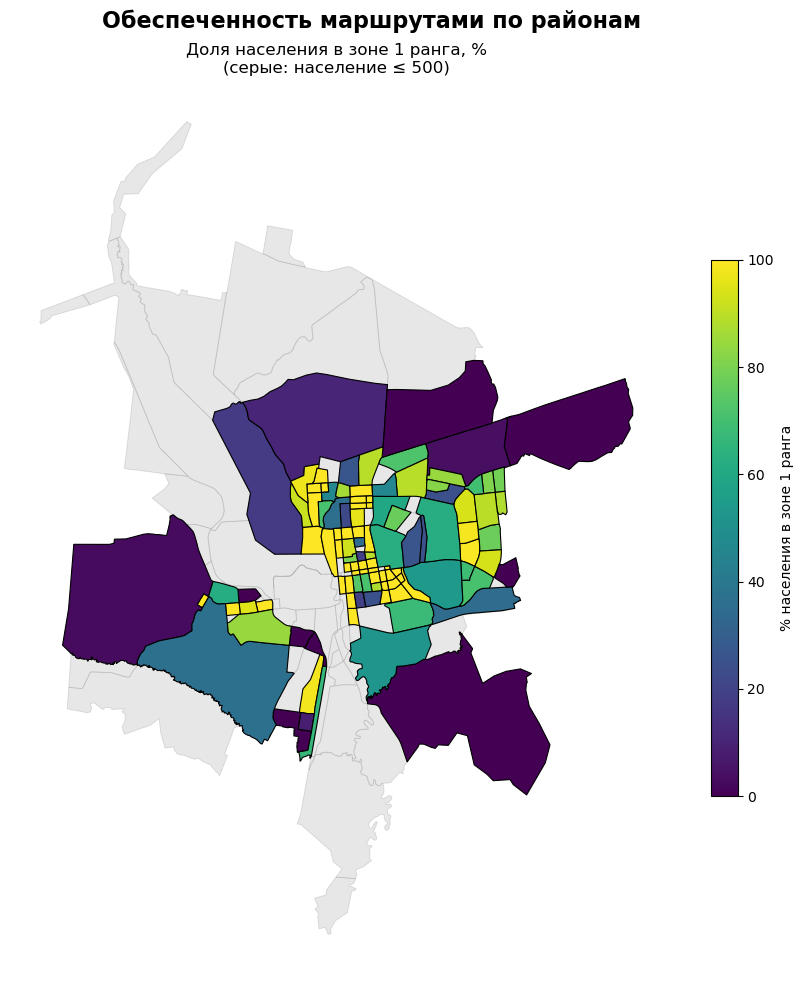

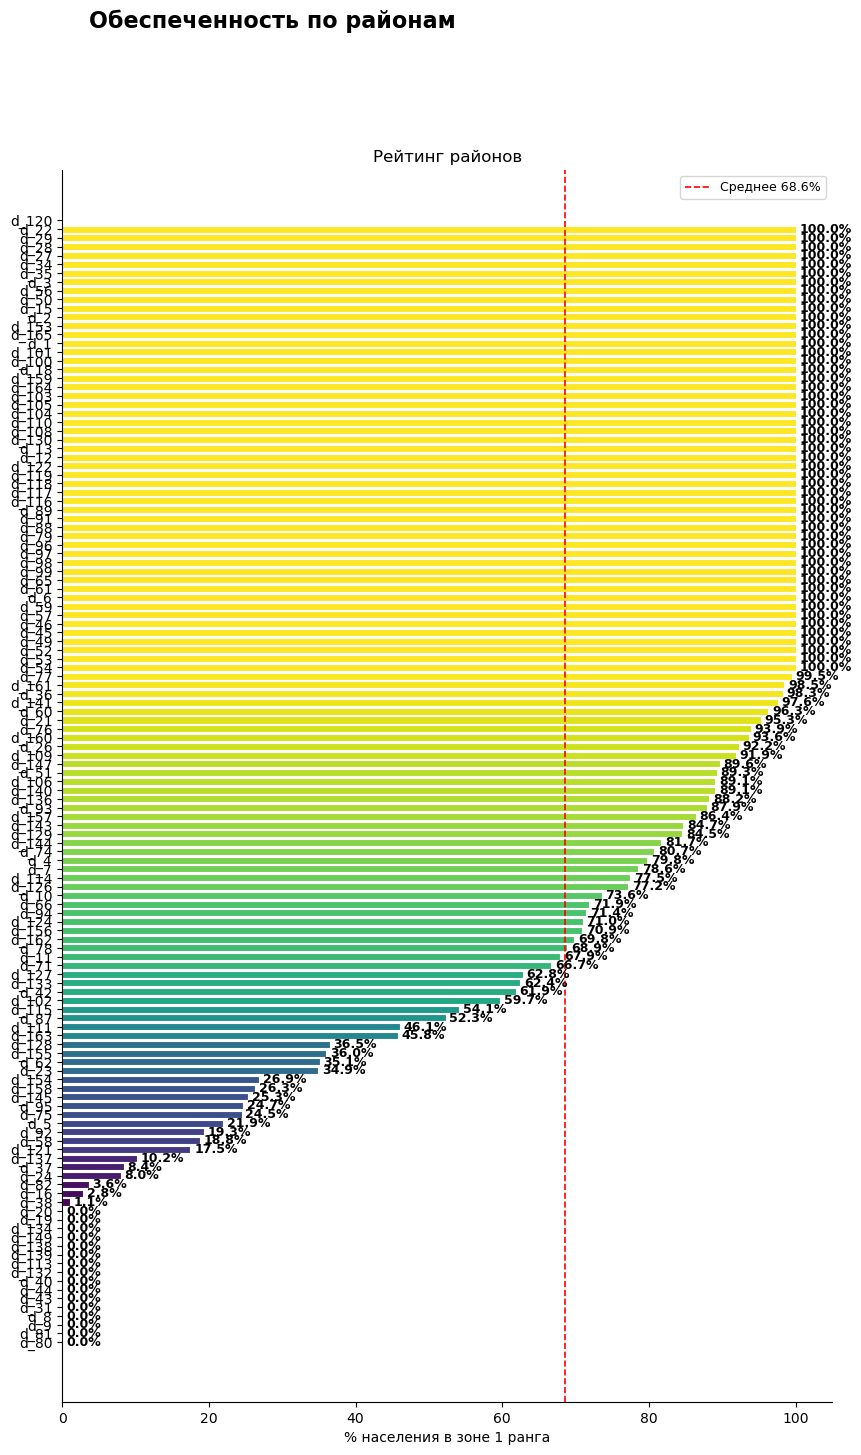

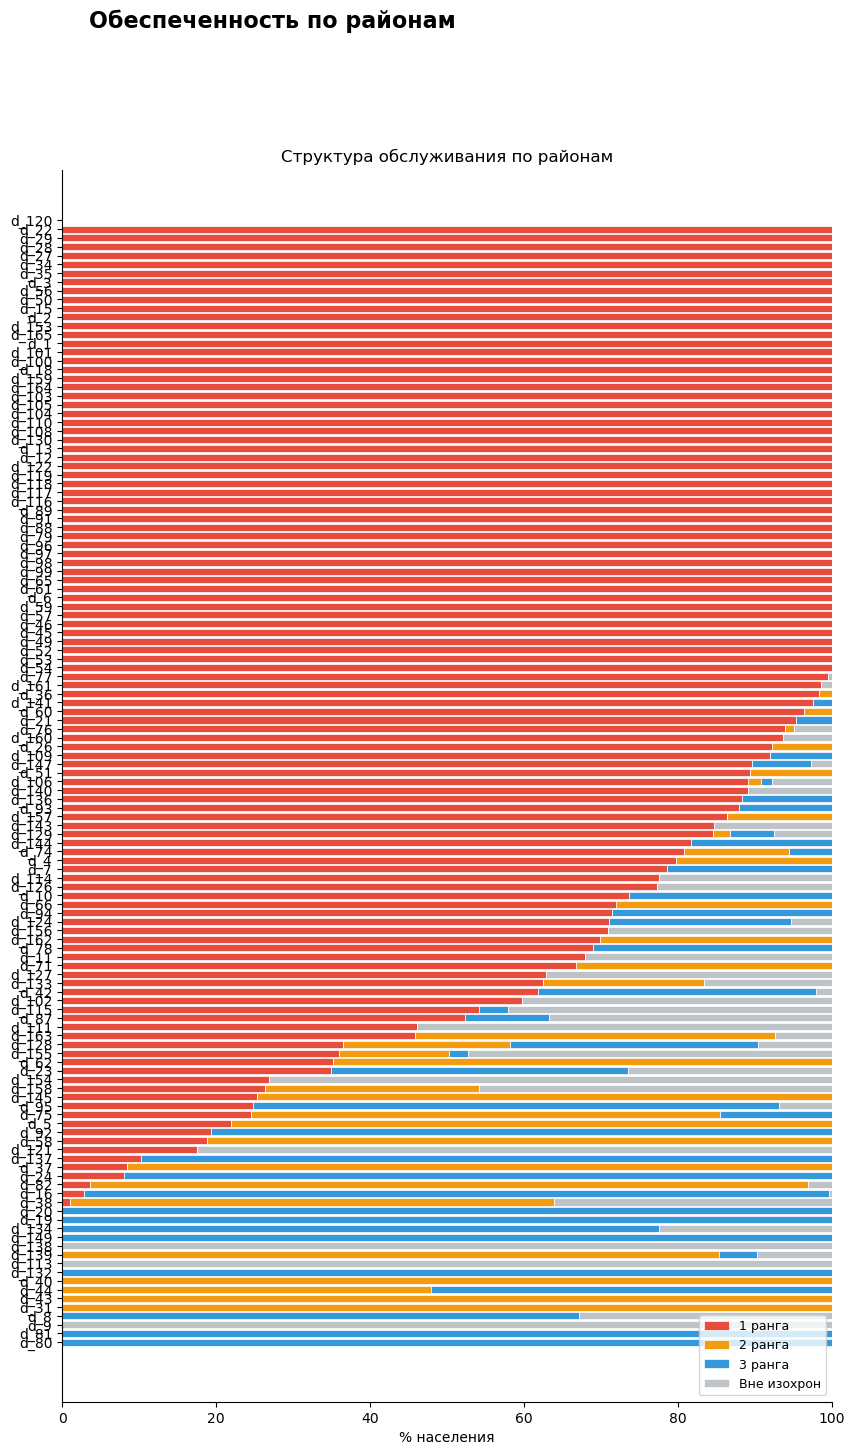

In [18]:
# ============================================================
# 7. ВИЗУАЛИЗАЦИЯ (3 отдельные картинки + экспорт каждой)
# ============================================================

# ---------- 7.1 Карта (<=500 серым полупрозрачным, >500 хороплет) ----------
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 10), facecolor='white')
fig1.suptitle('Обеспеченность маршрутами по районам',
              fontsize=16, fontweight='bold')

districts_viz['pop_total'] = districts_viz['pop_total'].fillna(0)

low_pop  = districts_viz[districts_viz['pop_total'] <= 500].copy()
high_pop = districts_viz[districts_viz['pop_total'] >  500].copy()

# 1) Сначала малонаселённые районы (серые)
if len(low_pop) > 0:
    low_pop.plot(
        ax=ax1,
        color='#bdbdbd',
        alpha=0.35,
        edgecolor='#9e9e9e',
        linewidth=0.6
    )

# 2) Сверху районы > 500 с заливкой по pct_m
if len(high_pop) > 0:
    high_pop.plot(
        column='pct_1r',
        cmap='viridis',
        edgecolor='black',
        linewidth=0.8,
        legend=True,
        legend_kwds={'label': '% населения в зоне 1 ранга', 'shrink': 0.6},
        ax=ax1
    )

ax1.set_title('Доля населения в зоне 1 ранга, %\n(серые: население ≤ 500)')
ax1.set_axis_off()

fig1.tight_layout()
fig1.savefig(fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\pic\{SCENARIO}_districts_01_map.png', dpi=200, bbox_inches='tight')

plt.show()

# ---------- 7.2 Рейтинг районов (высота x2) ----------
fig2, ax2 = plt.subplots(1, 1, figsize=(14, 16), facecolor='white')  # было ~8 по высоте, стало 16
fig2.suptitle('Обеспеченность по районам',
              fontsize=16, fontweight='bold')

sorted_stats = district_stats.sort_values('pct_1r', ascending=True)
bar_colors = plt.cm.viridis(sorted_stats['pct_1r'] / 100)

hbars = ax2.barh(
    sorted_stats.index,
    sorted_stats['pct_1r'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar, val in zip(hbars, sorted_stats['pct_1r']):
    ax2.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        ha='left', va='center',
        fontsize=9, fontweight='bold'
    )

ax2.axvline(
    district_stats['pct_1r'].mean(),
    color='red', linestyle='--', linewidth=1.2,
    label=f'Среднее {district_stats["pct_1r"].mean():.1f}%'
)

ax2.set_xlabel('% населения в зоне 1 ранга')
ax2.set_title('Рейтинг районов')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

# если названия районов длинные — полезно дать больше места слева:
fig2.subplots_adjust(left=0.35)

# fig2.tight_layout()
# fig2.savefig(f'{SCENARIO}_districts_02_rating_pct_m.png', dpi=200, bbox_inches='tight')
# plt.show()


# ---------- 7.3 Структура обслуживания (stacked bar, высота x2) ----------
fig3, ax3 = plt.subplots(1, 1, figsize=(14, 16), facecolor='white')  # высота x2
fig3.suptitle('Обеспеченность по районам',
              fontsize=16, fontweight='bold')

sorted_stats2 = district_stats.sort_values('pct_1r', ascending=True)
y_labels = sorted_stats2.index

pct_m_arr   = sorted_stats2['pop_1']   / sorted_stats2['pop_total'] * 100
pct_p_arr   = sorted_stats2['pop_2']   / sorted_stats2['pop_total'] * 100
pct_o_arr   = sorted_stats2['pop_3']   / sorted_stats2['pop_total'] * 100
pct_out_arr = sorted_stats2['pop_out'] / sorted_stats2['pop_total'] * 100

ax3.barh(y_labels, pct_m_arr,
         color='#e74c3c', label='1 ранга',
         edgecolor='white', linewidth=0.5)
ax3.barh(y_labels, pct_p_arr,
         left=pct_m_arr,
         color='#f39c12', label='2 ранга',
         edgecolor='white', linewidth=0.5)
ax3.barh(y_labels, pct_o_arr,
         left=pct_m_arr + pct_p_arr,
         color='#3498db', label='3 ранга',
         edgecolor='white', linewidth=0.5)
ax3.barh(y_labels, pct_out_arr,
         left=pct_m_arr + pct_p_arr + pct_o_arr,
         color='#bdc3c7', label='Вне изохрон',
         edgecolor='white', linewidth=0.5)

ax3.set_xlabel('% населения')
ax3.set_title('Структура обслуживания по районам')
ax3.legend(loc='lower right', fontsize=9)
ax3.set_xlim(0, 100)
ax3.spines[['top', 'right']].set_visible(False)

# если названия районов длинные — полезно дать больше места слева:
fig3.subplots_adjust(left=0.35)

# fig3.tight_layout()
# fig3.savefig(f'{SCENARIO}_districts_03_structure_stacked.png', dpi=200, bbox_inches='tight')
# plt.show()

In [19]:
# districts_viz.to_file(rf'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\district\district_tr_{SCENARIO}.gpkg')

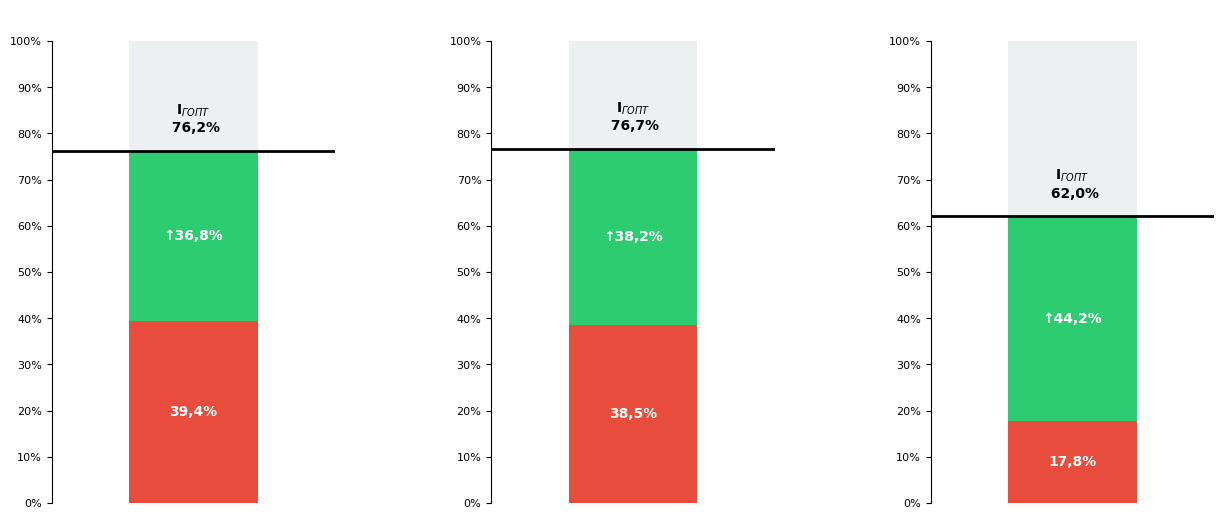

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Исходные данные
df = pd.DataFrame({
    'scenario': [1, 2, 3, 4, 5, 6],
    'prc': ['39,44', '76,2', '38,55', '76,73', '17,82', '62,04']
})

# Перевод процентов в доли 0..1
df['service_index'] = (
    df['prc'].astype(str).str.replace(',', '.', regex=False).astype(float) / 100
)

# Настройки графиков
chart_specs = [
    {'base_scenario': 1, 'new_scenario': 2, 'title': ' '},
    {'base_scenario': 3, 'new_scenario': 4, 'title': ' '},
    {'base_scenario': 5, 'new_scenario': 6, 'title': ' '},
]

scenario_to_index = df.set_index('scenario')['service_index'].to_dict()

def fmt_pct(value: float) -> str:
    return f'{value * 100:.1f}%'.replace('.', ',')

def fmt_pp(value: float) -> str:
    return f'↑{value * 100:.1f}%'.replace('.', ',')

def draw_plot_gauge_vertical(ax, base_index: float, new_index: float, title: str,
                             base_scenario: int, new_scenario: int) -> None:
    """Вертикальная шкала: базовый индекс красным, дельта зеленым, итоговый ИУО выше черной линии."""
    delta = new_index - base_index

    # Фон шкалы
    ax.bar(0, 1, color='#ecf0f1', width=0.68)

    # Базовый индекс
    ax.bar(0, base_index, color='#e74c3c', width=0.68)

    # Дельта
    if delta >= 0:
        ax.bar(0, delta, bottom=base_index, color='#2ecc71', width=0.68)
        delta_bottom = base_index
        delta_height = delta
    else:
        ax.bar(0, abs(delta), bottom=new_index, color='#2ecc71', width=0.68)
        delta_bottom = new_index
        delta_height = abs(delta)

    # Линия нового значения
    ax.axhline(new_index, color='black', linewidth=2)

    # Подпись базового значения внутри красной части
    if base_index > 0.08:
        ax.text(
            0, base_index / 2,
            fmt_pct(base_index),
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='white'
        )

    # Подпись дельты внутри зеленой части
    if delta_height > 0.06:
        ax.text(
            0, delta_bottom + delta_height / 2,
            fmt_pp(delta),
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='white'
        )
    else:
        ax.text(
            0, min(delta_bottom + delta_height + 0.03, 0.97),
            fmt_pp(delta),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color='#2c3e50'
        )

    # Итоговый ИУО выше черной линии
    ax.text(
        0,
        min(new_index + 0.035, 0.985),
        f'I$_{{ГОПТ}}$ \n {fmt_pct(new_index)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

    # Оси
    ax.set_ylim(0, 1)
    ax.set_xlim(-0.75, 0.75)
    ax.set_xticks([])

    ticks = np.arange(0, 1.1, 0.1)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{int(x * 100)}%' for x in ticks], fontsize=8)

    ax.set_title(title, fontsize=11, pad=14)

    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

# Построение графиков
fig, axes = plt.subplots(1, len(chart_specs), figsize=(15, 6), constrained_layout=False)

if len(chart_specs) == 1:
    axes = [axes]

for ax, spec in zip(axes, chart_specs):
    draw_plot_gauge_vertical(
        ax=ax,
        base_index=scenario_to_index[spec['base_scenario']],
        new_index=scenario_to_index[spec['new_scenario']],
        title=spec['title'],
        base_scenario=spec['base_scenario'],
        new_scenario=spec['new_scenario']
    )

fig.subplots_adjust(wspace=0.55)

# Сохранение рисунка
fig.savefig('service_index_delta_all_vertical.png', dpi=300, bbox_inches='tight')
plt.show()

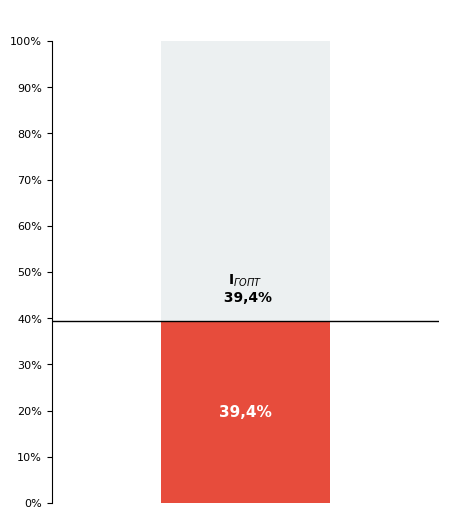

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Исходные данные
df = pd.DataFrame({
    'scenario': [1, 2, 3, 4, 5, 6],
    'prc': ['39,44', '76,2', '38,55', '76,73', '17,82', '62,04']
})

# Перевод процентов в доли 0..1
df['service_index'] = (
    df['prc'].astype(str).str.replace(',', '.', regex=False).astype(float) / 100
)

scenario_to_index = df.set_index('scenario')['service_index'].to_dict()

def fmt_pct(value: float) -> str:
    return f'{value * 100:.1f}%'.replace('.', ',')

def draw_plot_scenario1(ax, service_index: float, title: str, scenario: int) -> None:
    """Вертикальная шкала только для одного сценария."""
    # Фон шкалы
    ax.bar(0, 1, color='#ecf0f1', width=0.7)

    # Значение индекса
    ax.bar(0, service_index, color='#e74c3c', width=0.7)

    # Линия индикатора
    ax.axhline(service_index, color='black', linewidth=1)

    # Подпись внутри столбца
    if service_index > 0.08:
        ax.text(
            0, service_index / 2,
            fmt_pct(service_index),
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color='white'
        )

    # Подпись над черной линией
    ax.text(
        0,
        min(service_index + 0.035, 0.985),
        f'I$_{{ГОПТ}}$ \n {fmt_pct(service_index)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

    # Оси
    ax.set_ylim(0, 1)
    ax.set_xlim(-0.8, 0.8)
    ax.set_xticks([])

    ticks = np.arange(0, 1.1, 0.1)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f'{int(x * 100)}%' for x in ticks], fontsize=8)

    ax.set_title(title, fontsize=11, pad=14)

    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

# Построение только для сценария 1
fig, ax = plt.subplots(1, 1, figsize=(5, 6), constrained_layout=False)

draw_plot_scenario1(
    ax=ax,
    service_index=scenario_to_index[1],
    title=' ',
    scenario=1
)

# Сохранение рисунка
fig.savefig('service_index_scenario_1.png', dpi=300, bbox_inches='tight')
plt.show()